In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler

> DATA UNDERSTANDING

In [8]:
df=pd.read_csv('Sleep_Efficiency.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      452 non-null    int64  
 1   Age                     452 non-null    int64  
 2   Gender                  452 non-null    str    
 3   Bedtime                 452 non-null    str    
 4   Wakeup time             452 non-null    str    
 5   Sleep duration          452 non-null    float64
 6   Sleep efficiency        452 non-null    float64
 7   REM sleep percentage    452 non-null    int64  
 8   Deep sleep percentage   452 non-null    int64  
 9   Light sleep percentage  452 non-null    int64  
 10  Awakenings              432 non-null    float64
 11  Caffeine consumption    427 non-null    float64
 12  Alcohol consumption     438 non-null    float64
 13  Smoking status          452 non-null    str    
 14  Exercise frequency      446 non-null    float64
dtype

In [9]:
df.describe()

,ID,Age,Sleep duration,Sleep efficiency,REM sleep percentage,Deep sleep percentage,Light sleep percentage,Awakenings,Caffeine consumption,Alcohol consumption,Exercise frequency
count,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,432.000000,427.000000,438.000000,446.000000
mean,226.500000,40.285398,7.465708,0.788916,22.615044,52.823009,24.561947,1.641204,23.653396,1.173516,1.791480
std,130.625419,13.172250,0.866625,0.135237,3.525963,15.654235,15.313665,1.356762,30.202785,1.621377,1.428134
min,1.000000,9.000000,5.000000,0.500000,15.000000,18.000000,7.000000,0.000000,0.000000,0.000000,0.000000
25%,113.750000,29.000000,7.000000,0.697500,20.000000,48.250000,15.000000,1.000000,0.000000,0.000000,0.000000
50%,226.500000,40.000000,7.500000,0.820000,22.000000,58.000000,18.000000,1.000000,25.000000,0.000000,2.000000
75%,339.250000,52.000000,8.000000,0.900000,25.000000,63.000000,32.500000,3.000000,50.000000,2.000000,3.000000
max,452.000000,69.000000,10.000000,0.990000,30.000000,75.000000,63.000000,4.000000,200.000000,5.000000,5.000000


In [10]:
df.describe(include='O')

C:\Users\FASTECH LAPTOP\AppData\Local\Temp\ipykernel_24496\2537740217.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='O')


,Gender,Bedtime,Wakeup time,Smoking status
count,452,452,452,452
unique,2,424,434,2
top,Male,2021-03-11 01:00:00,2021-12-05 09:00:00,No
freq,228,3,2,298


> DUPLICATED VALUES


In [11]:
df['ID'].duplicated().sum()
df.duplicated().sum()

np.int64(0)

> NULL VALUES

In [12]:
df.isna().sum()

ID                         0
Age                        0
Gender                     0
Bedtime                    0
Wakeup time                0
Sleep duration             0
Sleep efficiency           0
REM sleep percentage       0
Deep sleep percentage      0
Light sleep percentage     0
Awakenings                20
Caffeine consumption      25
Alcohol consumption       14
Smoking status             0
Exercise frequency         6
dtype: int64

In [13]:
len(df[(df['Awakenings'].isna()) & (df['Caffeine consumption'].isna())])

1

> HIST PLOT DATA DISTRIBUTION & INTERPRETATION

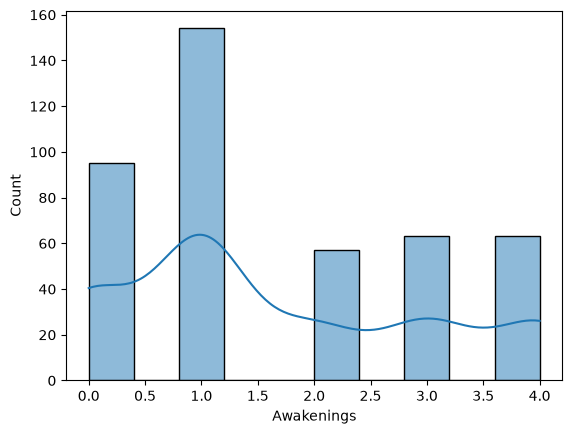

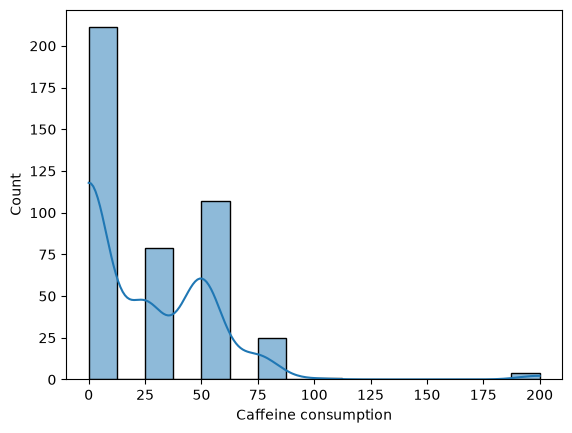

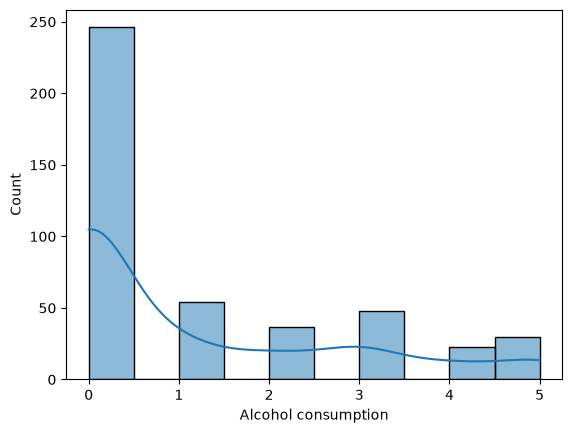

In [14]:
sns.histplot(data=df,x='Awakenings',kde=True)
plt.show()
sns.histplot(data=df,x='Caffeine consumption',kde=True)
plt.show()
sns.histplot(data=df,x='Alcohol consumption',kde=True)
plt.show()


In [15]:
print(df[['Awakenings',
          'Caffeine consumption',
          'Alcohol consumption']].describe())

       Awakenings  Caffeine consumption  Alcohol consumption
count  432.000000            427.000000           438.000000
mean     1.641204             23.653396             1.173516
std      1.356762             30.202785             1.621377
min      0.000000              0.000000             0.000000
25%      1.000000              0.000000             0.000000
50%      1.000000             25.000000             0.000000
75%      3.000000             50.000000             2.000000
max      4.000000            200.000000             5.000000


In [16]:
print(df[['Awakenings',
          'Caffeine consumption',
          'Alcohol consumption']].skew())

Awakenings              0.491805
Caffeine consumption    2.134105
Alcohol consumption     1.141060
dtype: float64


In [17]:
df.head()

,ID,Age,Gender,Bedtime,Wakeup time,Sleep duration,Sleep efficiency,REM sleep percentage,Deep sleep percentage,Light sleep percentage,Awakenings,Caffeine consumption,Alcohol consumption,Smoking status,Exercise frequency
0,1,65,Female,2021-03-06 01:00:00,2021-03-06 07:00:00,6.0,0.88,18,70,12,0.0,0.0,0.0,Yes,3.0
1,2,69,Male,2021-12-05 02:00:00,2021-12-05 09:00:00,7.0,0.66,19,28,53,3.0,0.0,3.0,Yes,3.0
2,3,40,Female,2021-05-25 21:30:00,2021-05-25 05:30:00,8.0,0.89,20,70,10,1.0,0.0,0.0,No,3.0
3,4,40,Female,2021-11-03 02:30:00,2021-11-03 08:30:00,6.0,0.51,23,25,52,3.0,50.0,5.0,Yes,1.0
4,5,57,Male,2021-03-13 01:00:00,2021-03-13 09:00:00,8.0,0.76,27,55,18,3.0,0.0,3.0,No,3.0


> AUTOMATING THE TASK FOR BEST IMPUTER USING GridSearchCV

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Columns with missing values
features = [
    'Awakenings',
    'Caffeine consumption',
    'Alcohol consumption'
]

X = df[features]
 
y = df['Sleep efficiency']

pipeline = Pipeline([
    ('imputer', SimpleImputer()),
    ('model', RandomForestRegressor(random_state=42))
])

param_grid = {
    'imputer__strategy': ['mean', 'median', 'most_frequent']
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid.fit(X, y)

print("Best imputation method:")
print(grid.best_params_)

print("Best CV score:")
print(grid.best_score_)

Best imputation method:
{'imputer__strategy': 'median'}
Best CV score:
-0.010817543594115077


> COMPARISON OF IMPUTATION TECHNNIQUES

In [19]:
import pandas as pd
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler

# 1. Select all numerical columns
num_cols = df.select_dtypes(include='number').columns

X = df[num_cols].copy()


# 2. Mean Imputation
mean_imputer = SimpleImputer(strategy='mean')

X_mean = pd.DataFrame(
    mean_imputer.fit_transform(X),
    columns=num_cols,
    index=df.index
)


# 3. Median Imputation
median_imputer = SimpleImputer(strategy='median')

X_median = pd.DataFrame(
    median_imputer.fit_transform(X),
    columns=num_cols,
    index=df.index
)

# 4. Most Frequent Imputation
mode_imputer = SimpleImputer(strategy='most_frequent')

X_mode = pd.DataFrame(
    mode_imputer.fit_transform(X),
    columns=num_cols,
    index=df.index
)


# 5. KNN Imputation
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

knn_imputer = KNNImputer(n_neighbors=5)

X_knn_scaled = knn_imputer.fit_transform(X_scaled)

# Convert back to original units
X_knn = pd.DataFrame(
    scaler.inverse_transform(X_knn_scaled),
    columns=num_cols,
    index=df.index
)


# 6. Check missing values
print("Original missing values:")
print(X.isna().sum())

print("\nAfter Mean:")
print(X_mean.isna().sum())

print("\nAfter Median:")
print(X_median.isna().sum())

print("\nAfter Most Frequent:")
print(X_mode.isna().sum())

print("\nAfter KNN:")
print(X_knn.isna().sum())


# 7. Compare your three columns
cols = [
    'Awakenings',
    'Caffeine consumption',
    'Alcohol consumption'
]


print("\n========== MEAN ==========")
print(X_mean[cols].describe())

print("\n========== MOST FREQUENT ==========")
print(X_mode[cols].describe())

print("\n========== MEDIAN ==========")
print(X_median[cols].describe())

print("\n========== KNN ==========")
print(X_knn[cols].describe())

print("\n========== ORIGINAL ==========")
print(X[cols].describe())

Original missing values:
ID                         0
Age                        0
Sleep duration             0
Sleep efficiency           0
REM sleep percentage       0
Deep sleep percentage      0
Light sleep percentage     0
Awakenings                20
Caffeine consumption      25
Alcohol consumption       14
Exercise frequency         6
dtype: int64

After Mean:
ID                        0
Age                       0
Sleep duration            0
Sleep efficiency          0
REM sleep percentage      0
Deep sleep percentage     0
Light sleep percentage    0
Awakenings                0
Caffeine consumption      0
Alcohol consumption       0
Exercise frequency        0
dtype: int64

After Median:
ID                        0
Age                       0
Sleep duration            0
Sleep efficiency          0
REM sleep percentage      0
Deep sleep percentage     0
Light sleep percentage    0
Awakenings                0
Caffeine consumption      0
Alcohol consumption       0
Exercise frequ

> FINAL IMPUTATION USING KNN

In [20]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

num_cols = df.select_dtypes(include='number').columns

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[num_cols])

imputer = KNNImputer(n_neighbors=5)
X_knn = imputer.fit_transform(X_scaled)

df[num_cols] = scaler.inverse_transform(X_knn)

df[num_cols] = df[num_cols].round(6)

print(df.isna().sum())

ID                        0
Age                       0
Gender                    0
Bedtime                   0
Wakeup time               0
Sleep duration            0
Sleep efficiency          0
REM sleep percentage      0
Deep sleep percentage     0
Light sleep percentage    0
Awakenings                0
Caffeine consumption      0
Alcohol consumption       0
Smoking status            0
Exercise frequency        0
dtype: int64


> DATE_TIME cols


In [21]:
import datetime as dt

In [22]:
df['Bedtime'].head()

0    2021-03-06 01:00:00
1    2021-12-05 02:00:00
2    2021-05-25 21:30:00
3    2021-11-03 02:30:00
4    2021-03-13 01:00:00
Name: Bedtime, dtype: str

In [23]:
df.columns

Index(['ID', 'Age', 'Gender', 'Bedtime', 'Wakeup time', 'Sleep duration',
       'Sleep efficiency', 'REM sleep percentage', 'Deep sleep percentage',
       'Light sleep percentage', 'Awakenings', 'Caffeine consumption',
       'Alcohol consumption', 'Smoking status', 'Exercise frequency'],
      dtype='str')

In [24]:
df['Bedtime']=df['Bedtime'].str.split(' ',expand=True).get(1)
df['Wakeup time']=df['Wakeup time'].str.split(' ',expand=True).get(1)

In [25]:
df['Bedtime']=pd.to_datetime(df['Bedtime'])#.dt.minute
df['Wakeup time']=pd.to_datetime(df['Wakeup time'])

#df['Total Sleep_hrs']=abs(pd.to_datetime(df['Bedtime']).dt.hour-pd.to_datetime(df['Wakeup time']).dt.hour)
df.drop(columns=['Bedtime','Wakeup time'],inplace=True)

C:\Users\FASTECH LAPTOP\AppData\Local\Temp\ipykernel_24496\997364489.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Bedtime']=pd.to_datetime(df['Bedtime'])#.dt.minute
C:\Users\FASTECH LAPTOP\AppData\Local\Temp\ipykernel_24496\997364489.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Wakeup time']=pd.to_datetime(df['Wakeup time'])


In [26]:
df.columns=df.columns.str.strip()

In [36]:
df.drop(columns=['ID'],inplace=True)
obj=df.select_dtypes(str)
nume=df.select_dtypes([int,float]).columns

In [28]:
di={}
for i in obj:
    di[i]=df[i].unique()
di  

{'Gender': <StringArray>
 ['Female', 'Male']
 Length: 2, dtype: str,
 'Smoking status': <StringArray>
 ['Yes', 'No']
 Length: 2, dtype: str}

In [29]:
#df.columns=df.rename(columns={'Target_Sleep efficiency':'Sleep efficiency'}).columns

> OUTLIERS HANDLING USING DISTRIBUTION

In [37]:
nume

Index(['Age', 'Sleep duration', 'Sleep efficiency', 'REM sleep percentage',
       'Deep sleep percentage', 'Light sleep percentage', 'Awakenings',
       'Caffeine consumption', 'Alcohol consumption', 'Exercise frequency'],
      dtype='str')

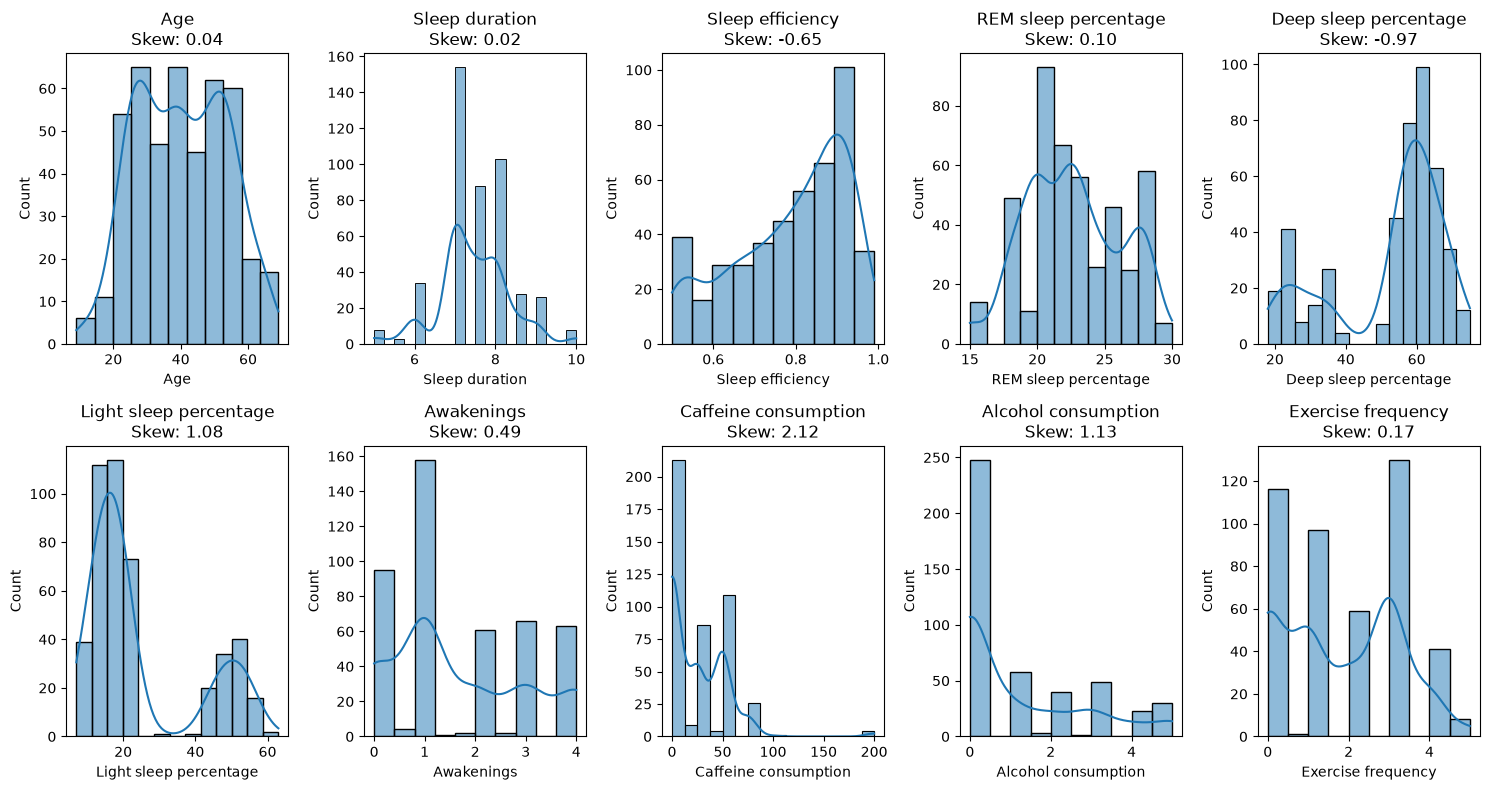

In [38]:
plt.figure(figsize=(15, 8))

for i, col in enumerate(nume):
    plt.subplot(2, 5, i+1)
    sns.histplot(df[col], kde=True)
    plt.title(f"{col}\nSkew: {df[col].skew():.2f}")

plt.tight_layout()
plt.show()

> BOX PLOTS WITH SKEW

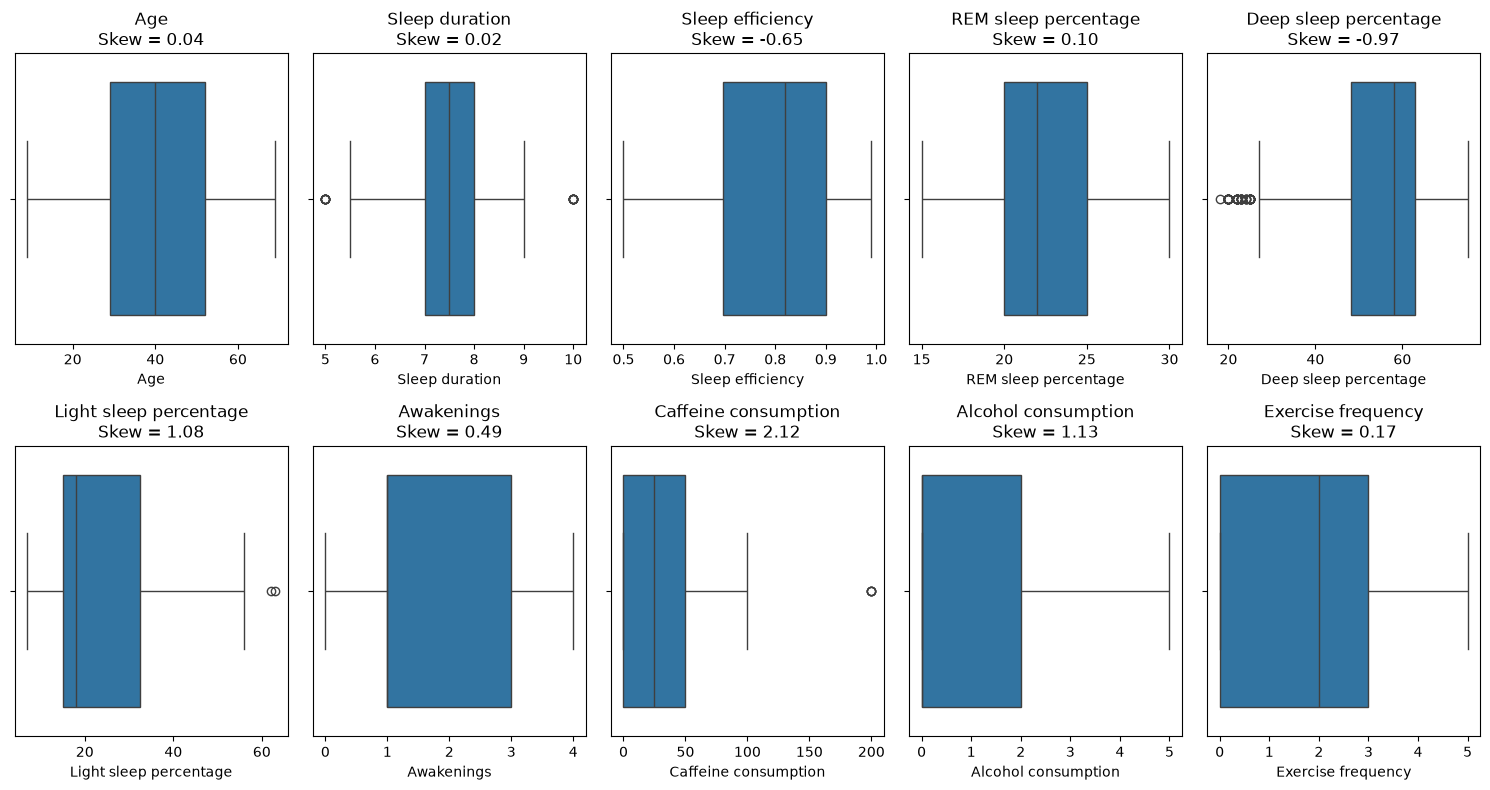

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))

for i, col in enumerate(nume):
    plt.subplot(2, 5, i + 1)
    sns.boxplot(x=df[col])
    plt.title(f"{col}\nSkew = {df[col].skew():.2f}")

plt.tight_layout()
plt.show()

>IQR RANGE

In [40]:
li=[]
dic={}
for i in (df.select_dtypes([float,int])):
    Q2,Q3=df[i].quantile([0.25,0.75])
    IQR=Q3-Q2
    low= Q2-1.5*IQR
    high=Q3+1.5*IQR

    dic[i]={'low_bound':low,'high_bound':high,'min':df[i].min() ,'max':df[i].max() ,'mean':df[i].mean() ,'no_outliers':df[(df[i]<low) | (df[i]>high)].shape[0] }
    li.append(li)
pd.DataFrame(dic)
    

,Age,Sleep duration,Sleep efficiency,REM sleep percentage,Deep sleep percentage,Light sleep percentage,Awakenings,Caffeine consumption,Alcohol consumption,Exercise frequency
low_bound,-5.500000,5.500000,0.393750,12.500000,26.125000,-11.250000,-2.00000,-75.000000,-3.000000,-4.500000
high_bound,86.500000,9.500000,1.203750,32.500000,85.125000,58.750000,6.00000,125.000000,5.000000,7.500000
min,9.000000,5.000000,0.500000,15.000000,18.000000,7.000000,-0.00000,0.000000,0.000000,0.000000
max,69.000000,10.000000,0.990000,30.000000,75.000000,63.000000,4.00000,200.000000,5.000000,5.000000
mean,40.285398,7.465708,0.788916,22.615044,52.823009,24.561947,1.64292,23.971239,1.186726,1.793363
no_outliers,0.000000,16.000000,0.000000,0.000000,60.000000,2.000000,0.00000,4.000000,0.000000,0.000000


In [41]:
num_cols=df.select_dtypes([float,int]).columns

> CONDITIONED CHECKING

In [42]:
for col in nume:

    skew = df[col].skew()

    if abs(skew) <= 0.5:
        # Approximately normal → 3-sigma bounds
        lower = df[col].mean() - 3 * df[col].std()
        upper = df[col].mean() + 3 * df[col].std()

    else:
        # Skewed → IQR bounds
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

    # Check whether outliers actually exist
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    if outliers > 0:
        print(f"{col}: {outliers} outliers → capping")

        df[col] = df[col].clip(lower, upper)

    else:
        print(f"{col}: No outliers, Not Chnaged")

Age: No outliers, Not Chnaged
Sleep duration: No outliers, Not Chnaged
Sleep efficiency: No outliers, Not Chnaged
REM sleep percentage: No outliers, Not Chnaged
Deep sleep percentage: 60 outliers → capping
Light sleep percentage: 2 outliers → capping
Awakenings: No outliers, Not Chnaged
Caffeine consumption: 4 outliers → capping
Alcohol consumption: No outliers, Not Chnaged
Exercise frequency: No outliers, Not Chnaged


In [ ]:
       num=(['Age', 'Sleep duration', 'Sleep efficiency',
              'REM sleep percentage', 'Deep sleep percentage',
              'Light sleep percentage', 'Awakenings', 'Caffeine consumption',
              'Alcohol consumption', 'Exercise frequency'])#.dtype= str)

<function matplotlib.pyplot.show(close=None, block=None)>

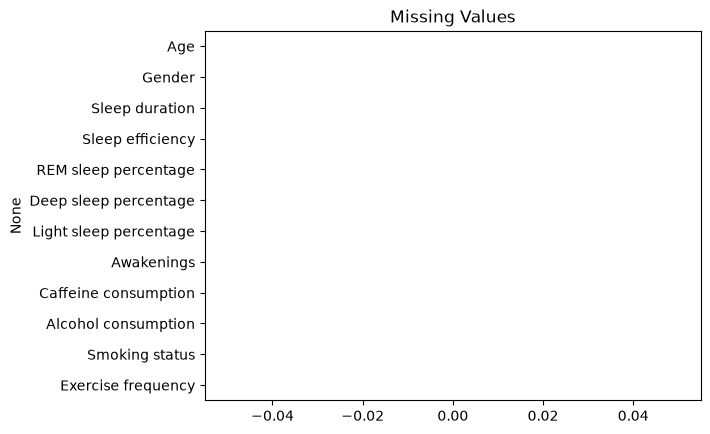

In [44]:
mis_val=df.isna().sum().sort_values(ascending=False)
sns.barplot(y=mis_val.index,x=mis_val.values,color='r')
plt.title('Missing Values')
plt.show

>CORRELATION MATRIX

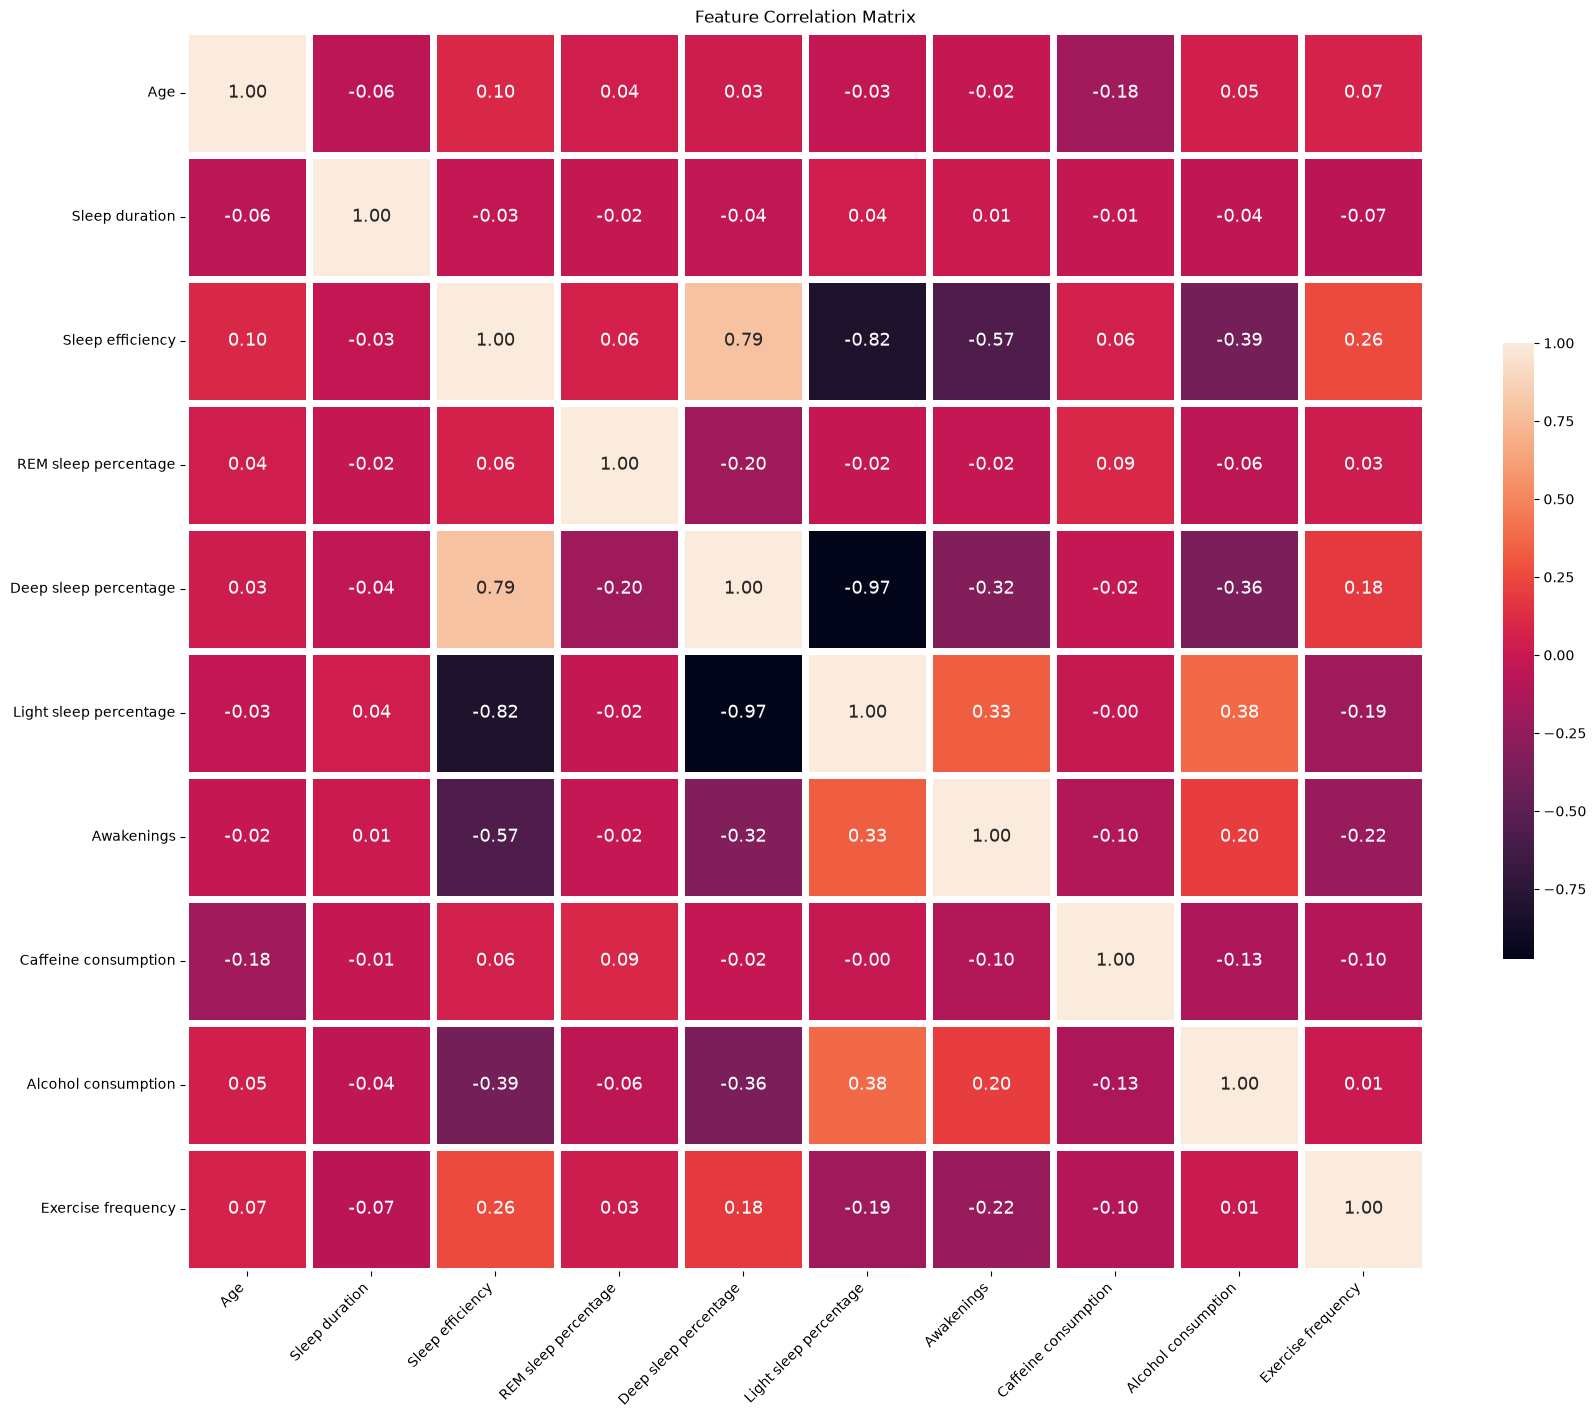

In [45]:
plt.figure(figsize=(20,20))
corr_matrix = df[num_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 13},
    linewidths=5,
    square=True,
    cbar_kws={"shrink": 0.4}
)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title('Feature Correlation Matrix')
#plt.tight_layout()
plt.show()

1. Awakenings               1.641204
2. Caffeine consumption    23.653396
3. Alcohol consumption      1.173516
4. Exercise frequency       1.791480

> Encoding

In [46]:
df[['Gender','Smoking status']]=pd.get_dummies(df[['Gender','Smoking status']] ,drop_first=True).replace([True,False],[1,0])
df.columns

Index(['Age', 'Gender', 'Sleep duration', 'Sleep efficiency',
       'REM sleep percentage', 'Deep sleep percentage',
       'Light sleep percentage', 'Awakenings', 'Caffeine consumption',
       'Alcohol consumption', 'Smoking status', 'Exercise frequency'],
      dtype='str')

In [47]:
from sklearn.model_selection import train_test_split
features = [
    'Age', 'Gender','Sleep duration',
    'REM sleep percentage', 'Deep sleep percentage',
    'Light sleep percentage', 'Awakenings', 'Caffeine consumption',
    'Alcohol consumption', 'Smoking status', 'Exercise frequency'
]

data=df[features] 
data=data.astype(float) 
target=df['Sleep efficiency']
x_train,x_test,y_train,y_test=train_test_split(data,target,test_size=0.2,random_state=42)


> SELECTING THE BEST FEATURES 

In [48]:
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

selector = RFECV(
    estimator=model,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

selector.fit(x_train, y_train)

print("Selected features:")
print(x_train.columns[selector.support_])

print("Number selected:", selector.n_features_)

Selected features:
Index(['Age', 'Gender', 'Sleep duration', 'REM sleep percentage',
       'Deep sleep percentage', 'Light sleep percentage', 'Awakenings',
       'Caffeine consumption', 'Alcohol consumption', 'Smoking status',
       'Exercise frequency'],
      dtype='str')
Number selected: 11


> || MODEL TRAINING

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRFRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

> LINEAR REGRESSION

In [ ]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()

scaler=StandardScaler()

model_lr.fit(x_train, y_train)

y_pred = model_lr.predict(x_test)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
print("R2:", r2_score(y_test, y_pred))

MAE: 0.04975489289581397
MSE: 0.003710376013050202
RMSE: 0.060912855893072375
R2: 0.8007109802675852


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

param = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_lr = GridSearchCV(
    Ridge(),
    param_grid=param,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_lr.fit(scaler.fit_transform(x_train), y_train)

print("MAE:", mean_absolute_error(y_test, grid_lr.predict(scaler.transform(x_test))))
print("MSE:", mean_squared_error(y_test, grid_lr.predict(scaler.transform(x_test))))
print("RMSE:", mean_squared_error(y_test, grid_lr.predict(scaler.transform(x_test))) ** 0.5)
print("R2:", r2_score(y_test, grid_lr.predict(scaler.transform(x_test))))

MAE: 0.050015078292193746
MSE: 0.0037173011075895936
RMSE: 0.06096967367133921
R2: 0.8003390246228055


> KNN

In [ ]:
param_knn = {
    'n_neighbors': [3, 5, 7, 10, 15, 20],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

grid_knn = GridSearchCV(
    KNeighborsRegressor(),
    param_grid=param_knn,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_knn.fit(scaler.fit_transform(x_train), y_train)

print("MAE:", mean_absolute_error(y_test, grid_knn.predict(scaler.transform(x_test))))
print("MSE:", mean_squared_error(y_test, grid_knn.predict(scaler.transform(x_test))))
print("RMSE:", mean_squared_error(y_test, grid_knn.predict(scaler.transform(x_test))) ** 0.5)
print("R2:", r2_score(y_test, grid_knn.predict(scaler.transform(x_test))))

MAE: 0.040610835109036764
MSE: 0.002945341775166682
RMSE: 0.05427100307868542
R2: 0.8418019432301789


> Decesion Tree

In [ ]:
param_dt = {
    'criterion': ['squared_error', 'absolute_error'],
    'max_depth': [3, 5, 10, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_leaf_nodes': [None, 10, 20, 50]
}

grid_dt = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid=param_dt,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_dt.fit(scaler.fit_transform(x_train), y_train)

print("MAE:", mean_absolute_error(y_test, grid_dt.predict(scaler.transform(x_test))))
print("MSE:", mean_squared_error(y_test, grid_dt.predict(scaler.transform(x_test))))
print("RMSE:", mean_squared_error(y_test, grid_dt.predict(scaler.transform(x_test))) ** 0.5)
print("R2:", r2_score(y_test, grid_dt.predict(scaler.transform(x_test))))

MAE: 0.04004213739350464
MSE: 0.00262318181039383
RMSE: 0.0512170070425228
R2: 0.8591055651139974


> RANDOM_FOREST

In [ ]:
param_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': [1.0, 'sqrt']
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_rf,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_rf.fit(x_train, y_train)
print(grid_rf.best_params_)

print("MAE:", mean_absolute_error(y_test, grid_rf.predict(x_test)))
print("MSE:", mean_squared_error(y_test, grid_rf.predict(x_test)))
print("RMSE:", mean_squared_error(y_test, grid_rf.predict(x_test)) ** 0.5)
print("R2:", r2_score(y_test, grid_rf.predict(x_test)))

MAE: 0.03665122518284831
MSE: 0.002397963620836802
RMSE: 0.048969006737290495
R2: 0.8712023208241637


In [ ]:
from sklearn.metrics import mean_absolute_percentage_error

y_pred = grid_rf.predict(x_test)

mape = mean_absolute_percentage_error(y_test, y_pred)

accuracy = (1 - mape) * 100

print("Estimated accuracy:", accuracy, "%")

Estimated accuracy: 95.16044609791959 %


> SVM

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_svr = {
    'kernel': ['linear', 'rbf'],
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.5, 1],
    'gamma': ['scale', 'auto', 0.01, 0.1]
}

grid_svr = GridSearchCV(
    SVR(),
    param_grid=param_svr,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_svr.fit(x_train, y_train)

print("MAE:", mean_absolute_error(y_test, grid_svr.predict(x_test)))
print("MSE:", mean_squared_error(y_test, grid_svr.predict(x_test)))
print("RMSE:", mean_squared_error(y_test, grid_svr.predict(x_test)) ** 0.5)
print("R2:", r2_score(y_test, grid_svr.predict(x_test)))

MAE: 0.04537314816296161
MSE: 0.003975562096181078
RMSE: 0.06305205861969201
R2: 0.786467498106222


> XGBOOST

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor    
param_xgb = {
    'n_estimators': [ 300, 500,700],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [ 5,7,15,20],
    'gamma': [0, 0.1, 0.3]
}

grid_xgb = RandomizedSearchCV(
    XGBRegressor(
        objective='reg:squarederror',
        random_state=42
    ),
    param_grid=param_xgb,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_xgb.fit(x_train, y_train)

print(grid_xgb.best_params_)
print(grid_xgb.best_score_)

KeyboardInterrupt: 

> MODEL EVALUATION

In [ ]:
results = {
    'Linear/Ridge': grid_lr,
    'KNN': grid_knn,
    'Decision Tree': grid_dt,
    'Random Forest': grid_rf,
    'SVR': grid_svr,
    'XGBoost': grid_xgb
}

for name, model in results.items():
    print(f"\n{name}")
    print("Best Parameters:", model.best_params_)
    print("Best CV MSE:", -model.best_score_)


Linear/Ridge
Best Parameters: {'alpha': 10}
Best CV MSE: 0.00385673407357187

KNN
Best Parameters: {'n_neighbors': 10, 'p': 2, 'weights': 'distance'}
Best CV MSE: 0.003324075064055567

Decision Tree
Best Parameters: {'criterion': 'squared_error', 'max_depth': 3, 'max_leaf_nodes': None, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best CV MSE: 0.0026550229247706445

Random Forest
Best Parameters: {'max_depth': 5, 'max_features': 1.0, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best CV MSE: 0.0024874122006733005

SVR
Best Parameters: {'kernel': 'rbf', 'gamma': 0.01, 'epsilon': 0.01, 'C': 1}
Best CV MSE: 0.003149173998480842

XGBoost
Best Parameters: {'subsample': 0.7, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.8}
Best CV MSE: 0.002582615428602855


In [ ]:
models = {
    'Ridge': grid_lr.best_estimator_,
    'KNN': grid_knn.best_estimator_,
    'Decision Tree': grid_dt.best_estimator_,
    'Random Forest': grid_rf.best_estimator_,
    'SVR': grid_svr.best_estimator_,
    'XGBoost': grid_xgb.best_estimator_
}

for name, model in models.items():

    # use scaled test data for KNN/SVR
    if name in ['KNN', 'SVR']:
        pred = model.predict(scaler.transform(x_test))
    else:
        pred = model.predict(x_test)

    print(f"\n{name}")
    print("MAE :", mean_absolute_error(y_test, pred))
    print("RMSE:", mean_squared_error(y_test, pred) ** 0.5)
    print("R²  :", r2_score(y_test, pred))


Ridge
MAE : 0.05011058643057448
RMSE: 0.061111178712832795
R²  : 0.7994111593659328

KNN
MAE : 0.040610835109036764
RMSE: 0.05427100307868542
R²  : 0.8418019432301789

Decision Tree
MAE : 0.04004213739350464
RMSE: 0.0512170070425228
R²  : 0.8591055651139974

Random Forest
MAE : 0.036651225182848295
RMSE: 0.048969006737290495
R²  : 0.8712023208241638

SVR
MAE : 0.04161426948024596
RMSE: 0.05271418582864376
R²  : 0.8507478988681563

XGBoost
MAE : 0.036969587121691024
RMSE: 0.0494482237800216
R²  : 0.8686691245430391
